In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import re, nltk, os

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

## Enable inline plotting (Kaggle compatibility)
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [28]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [31]:
## Set a nice seaborn style
sns.set(style='whitegrid')

In [32]:
news_df = pd.read_csv("fake_news_dataset.csv")

In [33]:
news_df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


DATA UNDERSTANDING

In [34]:
news_df.shape

(20000, 7)

In [35]:
news_df.describe()


,title,text,date,source,author,category,label
count,20000,20000,20000,19000,19000,20000,20000
unique,20000,20000,1096,8,17051,7,2
top,Foreign Democrat final.,more tax development both store agreement lawy...,2023-08-31,Daily News,Michael Smith,Health,fake
freq,1,1,32,2439,12,2922,10056


In [36]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   date      20000 non-null  object
 3   source    19000 non-null  object
 4   author    19000 non-null  object
 5   category  20000 non-null  object
 6   label     20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB


In [37]:
## Check for missing values
missing_values = news_df.isnull().sum()
print('Missing values by column:')
print(missing_values)

Missing values by column:
title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64


In [38]:
news_df.columns

Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object')

DATA PREPROCESSING

In [39]:
## Convert Date Column
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   title     20000 non-null  object        
 1   text      20000 non-null  object        
 2   date      20000 non-null  datetime64[ns]
 3   source    19000 non-null  object        
 4   author    19000 non-null  object        
 5   category  20000 non-null  object        
 6   label     20000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.1+ MB


In [40]:
## Drop rows with missing labels or text
news_df = news_df.dropna(subset=['label', 'text'])

In [41]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   title     20000 non-null  object        
 1   text      20000 non-null  object        
 2   date      20000 non-null  datetime64[ns]
 3   source    19000 non-null  object        
 4   author    19000 non-null  object        
 5   category  20000 non-null  object        
 6   label     20000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.1+ MB


In [42]:
## Check for missing values in 'source' and 'author'
missing_counts = news_df[['source', 'author']].isnull().sum()

## Calculate percentage of missing values
missing_percent = news_df[['source', 'author']].isnull().mean() * 100

In [43]:
## Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage': missing_percent
})

print(missing_summary)

        Missing Count  Missing Percentage
source           1000                 5.0
author           1000                 5.0


In [44]:
## Fill missing values with 'Unknown'
news_df['source'] = news_df['source'].fillna('Unknown')
news_df['author'] = news_df['author'].fillna('Unknown')

In [45]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   title     20000 non-null  object        
 1   text      20000 non-null  object        
 2   date      20000 non-null  datetime64[ns]
 3   source    20000 non-null  object        
 4   author    20000 non-null  object        
 5   category  20000 non-null  object        
 6   label     20000 non-null  object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.1+ MB


Exploratory Data Analysis

In [48]:
## Set the figure size for our plots
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [49]:
df = news_df.copy()

In [50]:
## Count of each label
label_counts = df['label'].value_counts()

## Percentage distribution
label_percent = df['label'].value_counts(normalize=True) * 100

## Combine into a summary table
label_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage': label_percent.round(2)
})

print(label_summary)

       Count  Percentage
label                   
fake   10056       50.28
real    9944       49.72


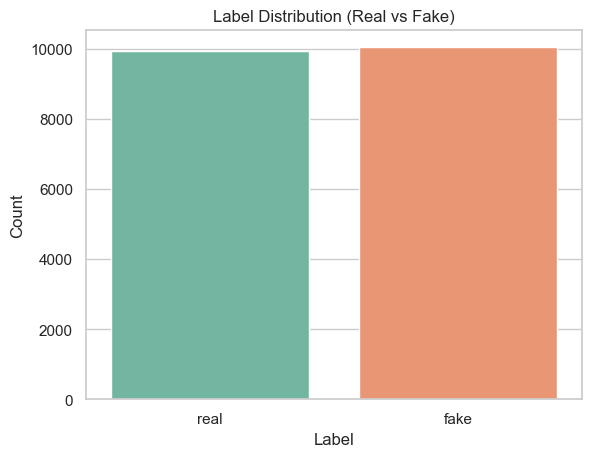

In [51]:
## Label Distribution plot
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Label Distribution (Real vs Fake)')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [52]:
## Add new columns for word counts
df['title_word_count'] = df['title'].fillna('').apply(lambda x: len(x.split()))
df['text_word_count'] = df['text'].fillna('').apply(lambda x: len(x.split()))

In [53]:
## Descriptive stats
print("Title Word Count Stats:")
print(df['title_word_count'].describe())

print("\nText Word Count Stats:")
print(df['text_word_count'].describe())

Title Word Count Stats:
count    20000.000000
mean         5.498350
std          1.450208
min          3.000000
25%          4.000000
50%          6.000000
75%          7.000000
max          8.000000
Name: title_word_count, dtype: float64

Text Word Count Stats:
count    20000.000000
mean       250.183300
std         29.079644
min        200.000000
25%        225.000000
50%        250.000000
75%        275.000000
max        300.000000
Name: text_word_count, dtype: float64


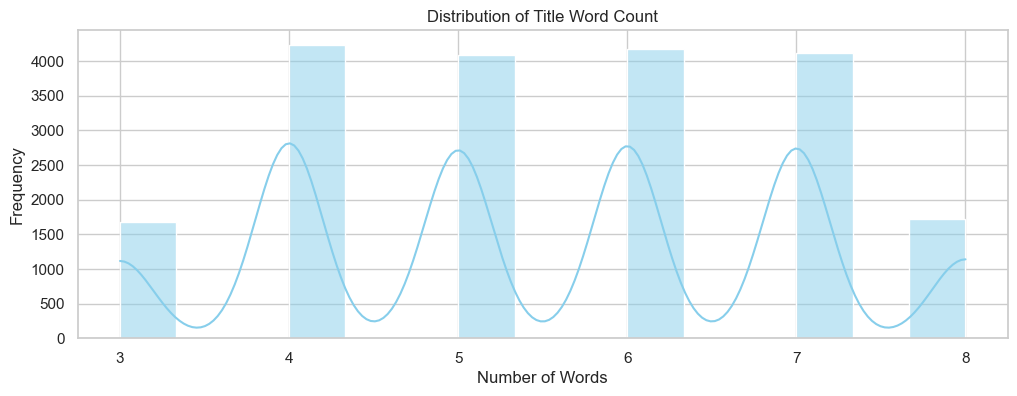

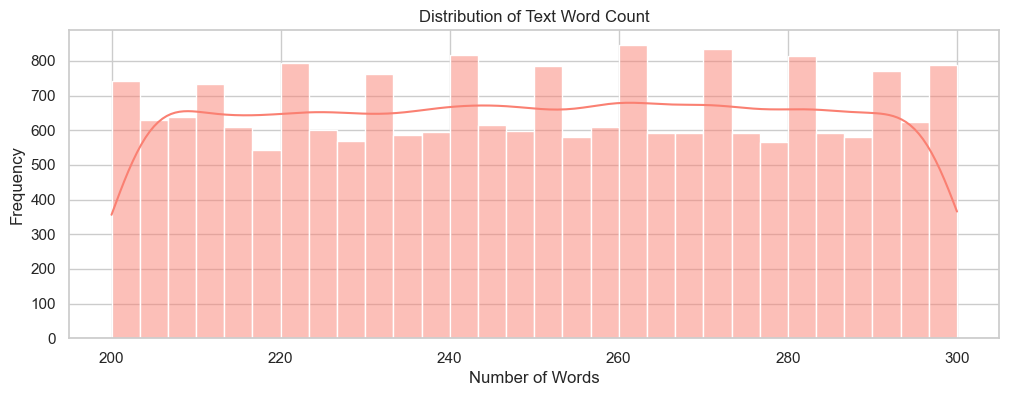

In [54]:
## Visualize the text length in a plot

# Title word count
plt.figure(figsize=(12, 4))
sns.histplot(df['title_word_count'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Title Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Text word count
plt.figure(figsize=(12, 4))
sns.histplot(df['text_word_count'], bins=30, kde=True, color='salmon')
plt.title('Distribution of Text Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [55]:
## Count of articles per category
category_counts = df['category'].value_counts()

## Percentage distribution
category_percent = df['category'].value_counts(normalize=True) * 100

## Combine into a summary table
category_summary = pd.DataFrame({
    'Count': category_counts,
    'Percentage': category_percent.round(2)
})

print(category_summary)

               Count  Percentage
category                        
Health          2922       14.61
Entertainment   2889       14.44
Technology      2882       14.41
Sports          2867       14.34
Business        2849       14.24
Politics        2802       14.01
Science         2789       13.94


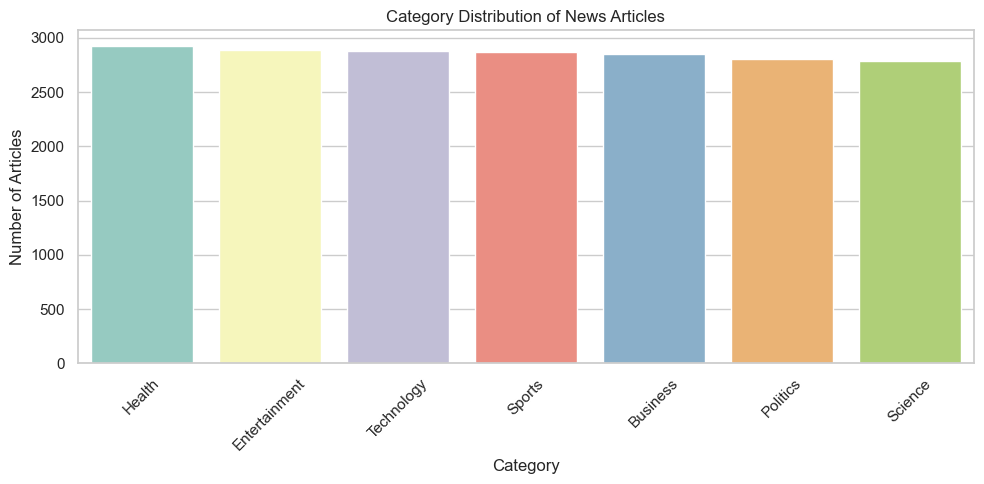

In [56]:

## Category Distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='category', order=df['category'].value_counts().index, palette='Set3')
plt.title('Category Distribution of News Articles')
plt.ylabel('Number of Articles')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
## Date Distribution

## For finer trends, group by date
daily_counts = df.groupby(df['date'].dt.date).size()

## For broader trends, group by month
monthly_counts = df.groupby(df['date'].dt.to_period('M')).size()
monthly_counts.index = monthly_counts.index.to_timestamp()

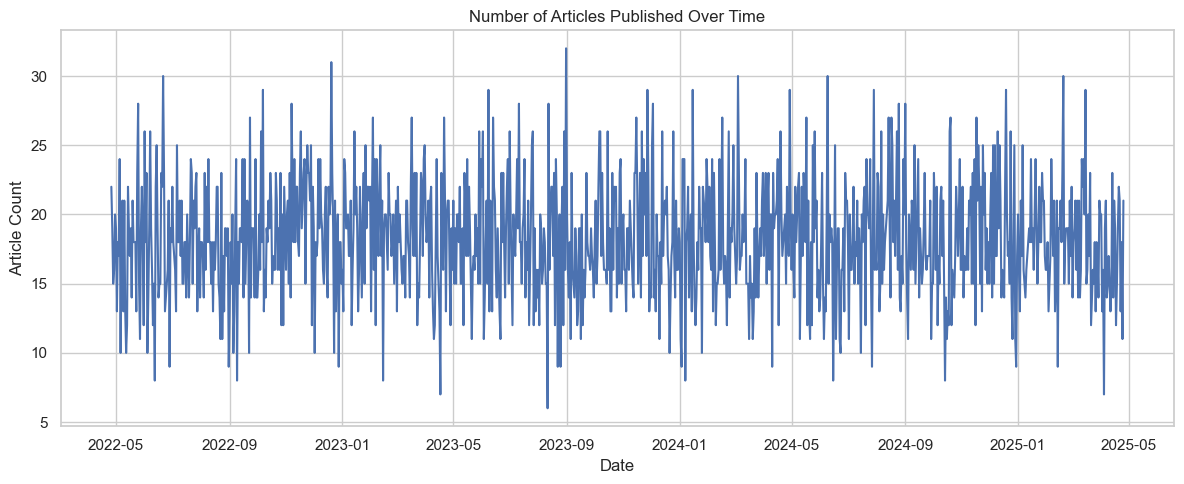

In [58]:
## Plot daily counts (use monthly_counts for monthly trends)
plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title("Number of Articles Published Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.grid(True)
plt.tight_layout()
plt.show()

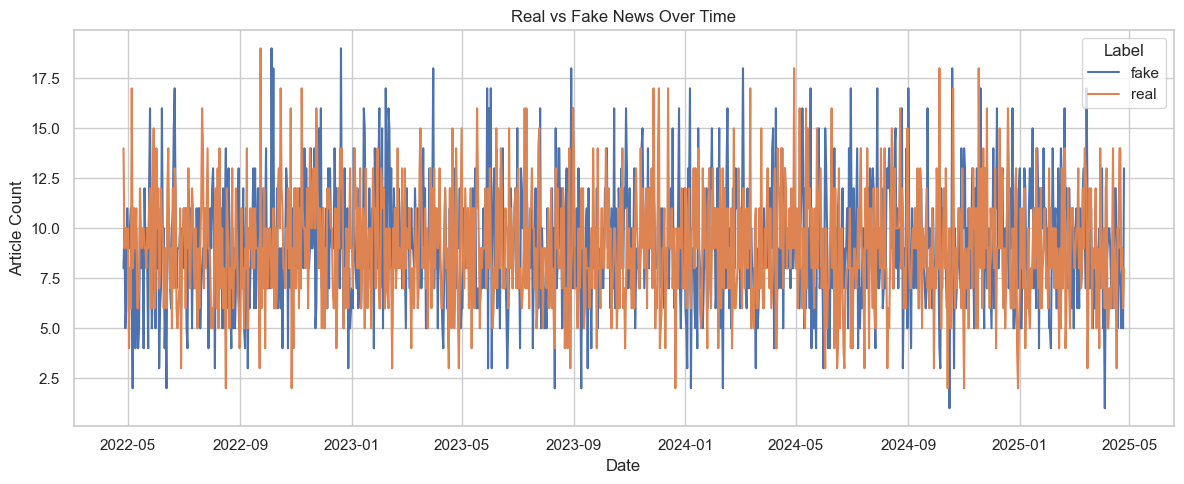

In [59]:
## Compare real vs fake over time

## Group by date and label
label_date_counts = df.groupby([df['date'].dt.date, 'label']).size().unstack()

# Plot
label_date_counts.plot(figsize=(12, 5))
plt.title("Real vs Fake News Over Time")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()

In [60]:
category_label_crosstab = pd.crosstab(df['category'], df['label'])
print(category_label_crosstab)

label          fake  real
category                 
Business       1471  1378
Entertainment  1460  1429
Health         1482  1440
Politics       1399  1403
Science        1376  1413
Sports         1444  1423
Technology     1424  1458


In [61]:
category_label_percent = pd.crosstab(df['category'], df['label'], normalize='index') * 100
print(category_label_percent.round(2))

label           fake   real
category                   
Business       51.63  48.37
Entertainment  50.54  49.46
Health         50.72  49.28
Politics       49.93  50.07
Science        49.34  50.66
Sports         50.37  49.63
Technology     49.41  50.59


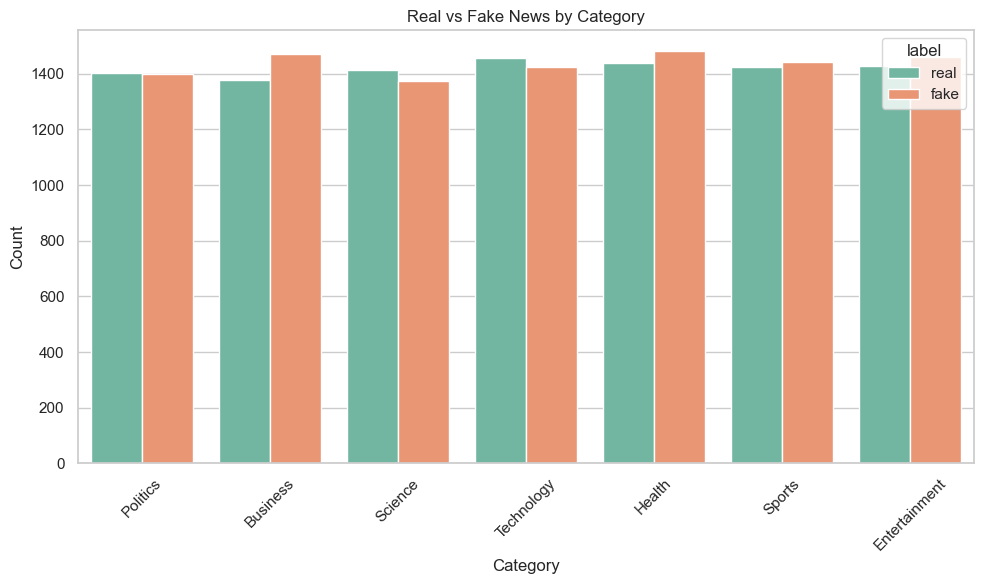

In [62]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', hue='label', palette='Set2')
plt.title('Real vs Fake News by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
from scipy.stats import chi2_contingency

def cramers_v(matrix):
    """Cramer's V for categorical variables."""
    chi2, p, dof, ex = chi2_contingency(matrix)
    n = matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(matrix.shape) - 1)))

# Create a cross-tabulation of 'label' vs 'category'
category_label_crosstab = pd.crosstab(df['category'], df['label'])

# Compute Cramér's V
cramers_v_value = cramers_v(category_label_crosstab)
print("Cramér's V between category and label:", cramers_v_value)

Cramér's V between category and label: 0.014826621111248231
